**Week 2 Assignment Submission**

**Student Details**

Name: Mahesh Shinde

College: Sanjivani College of Engineering, Kopargaon

---
**End-to-End Tesla EA Deliveries & Production - ML Pipeline**

**Dataset:** Tesla EA Deliveries and Production Data

**Goal:** Build a complete ML pipeline covering EDA, preprocessing, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

---
## 1. Installing & Importing required dependencies

In [56]:
!pip install kagglehub[pandas-datasets] scikit-learn xgboost lightgbm statsmodels matplotlib seaborn --quiet

In [57]:
!pip install kagglehub[pandas-datasets] scikit-learn xgboost lightgbm statsmodels matplotlib seaborn --quiet

In [58]:
# Standard imports for the entire pipeline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2.Loading the Dataset

In [59]:
# Load the Tesla dataset directly from Kaggle using kagglehub
import kagglehub
from kagglehub import KaggleDatasetAdapter

import kagglehub as kh
path = kh.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")
print("Downloaded to:", path)

import os
files = os.listdir(path)
print("Files in dataset:", files)

Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Downloaded to: /kaggle/input/tesla-ea-deliveries-and-production-data20152025
Files in dataset: ['tesla_deliveries_dataset_2015_2025.csv']


In [60]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "nalisha/tesla-ea-deliveries-and-production-data20152025",
    files[0]
)

print(f"Dataset shape: {df.shape}")
df.head()

Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Dataset shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


---
## 3. Initial data inspection

In [61]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Data Types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


In [62]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [63]:
# Check for missing values across all columns
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing >= 0])

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [64]:
# Unique value counts for categorical columns
for col in ['Region', 'Model']:
    if col in df.columns:
        print(f"{col} — {df[col].nunique()} unique values: {df[col].unique().tolist()}")

Region — 4 unique values: ['Europe', 'Asia', 'North America', 'Middle East']
Model — 5 unique values: ['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']


---
## 4. Exploratory Data Analysis (EDA)

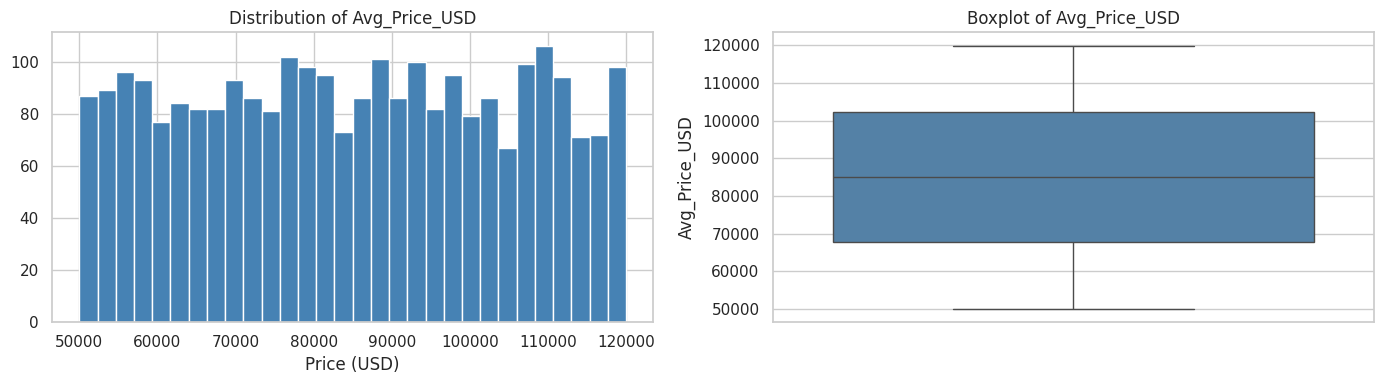

In [65]:
# Distribution of the target variable — Avg_Price_USD
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Avg_Price_USD'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Avg_Price_USD')
axes[0].set_xlabel('Price (USD)')

sns.boxplot(y=df['Avg_Price_USD'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of Avg_Price_USD')
plt.tight_layout()
plt.show()

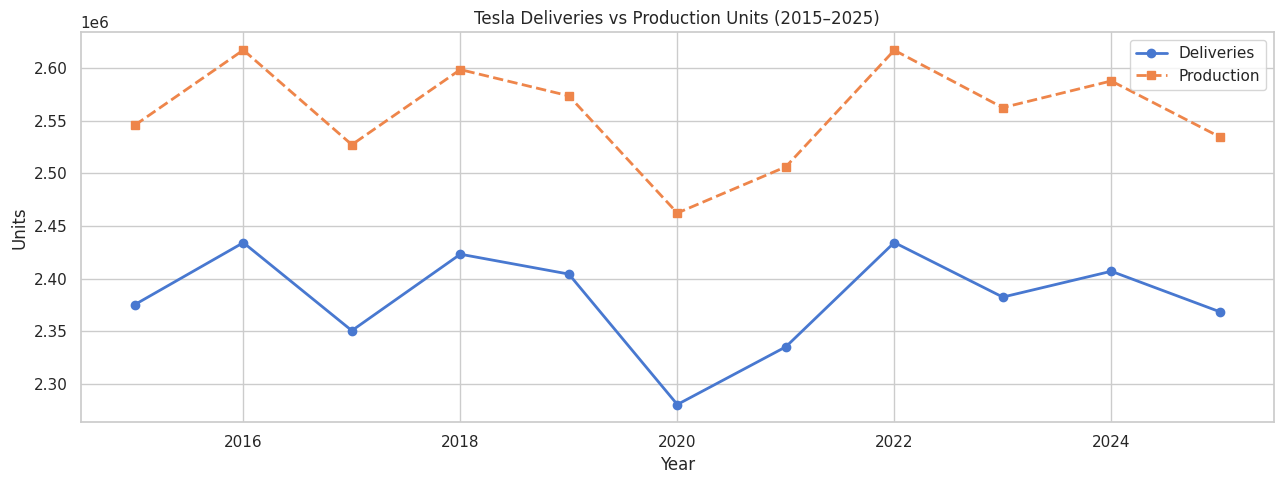

In [66]:
# Yearly trend of estimated deliveries — how Tesla has grown over time
yearly = df.groupby('Year')[['Estimated_Deliveries', 'Production_Units']].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(yearly['Year'], yearly['Estimated_Deliveries'], marker='o', label='Deliveries', linewidth=2)
ax.plot(yearly['Year'], yearly['Production_Units'], marker='s', label='Production', linewidth=2, linestyle='--')
ax.set_title('Tesla Deliveries vs Production Units (2015–2025)')
ax.set_xlabel('Year')
ax.set_ylabel('Units')
ax.legend()
plt.tight_layout()
plt.show()

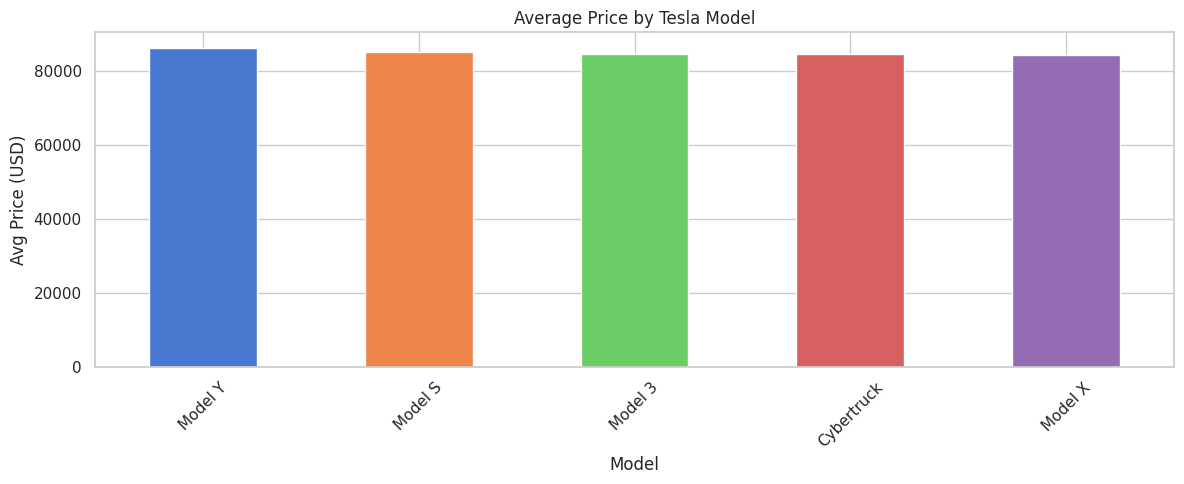

In [67]:
# Average price by Model — which models are positioned at higher price points
if 'Model' in df.columns:
    model_price = df.groupby('Model')['Avg_Price_USD'].mean().sort_values(ascending=False)
    model_price.plot(kind='bar', color=sns.color_palette('muted', len(model_price)), edgecolor='white')
    plt.title('Average Price by Tesla Model')
    plt.ylabel('Avg Price (USD)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

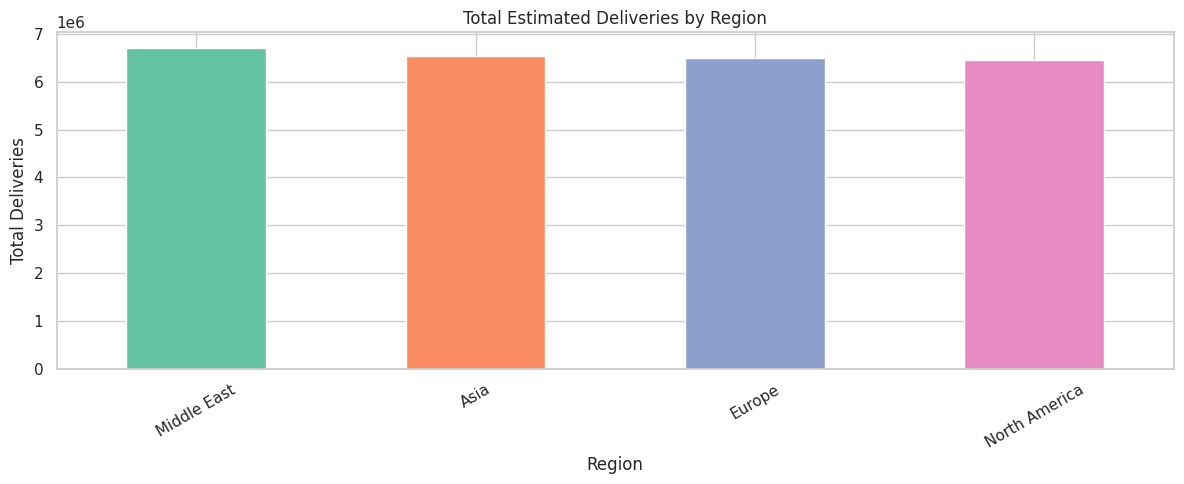

In [68]:
# Deliveries by Region — understanding geographic demand distribution
if 'Region' in df.columns:
    region_del = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
    region_del.plot(kind='bar', color=sns.color_palette('Set2', len(region_del)), edgecolor='white')
    plt.title('Total Estimated Deliveries by Region')
    plt.ylabel('Total Deliveries')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

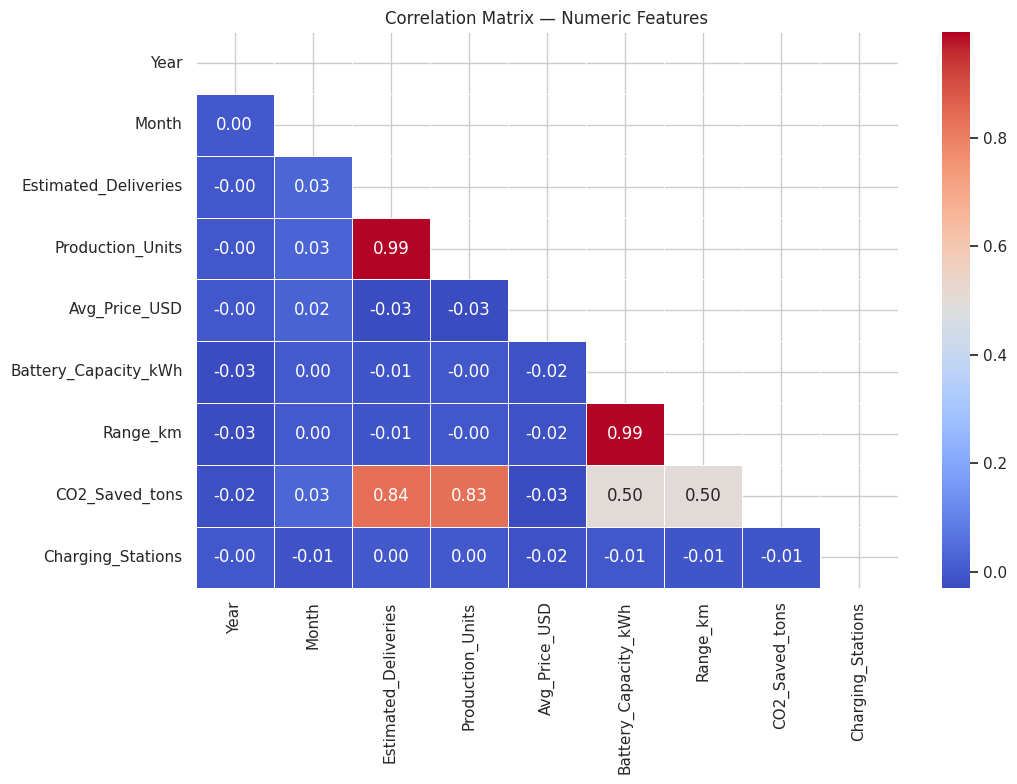

In [69]:
# Correlation heatmap of numeric features — helps spot multicollinearity before modeling
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

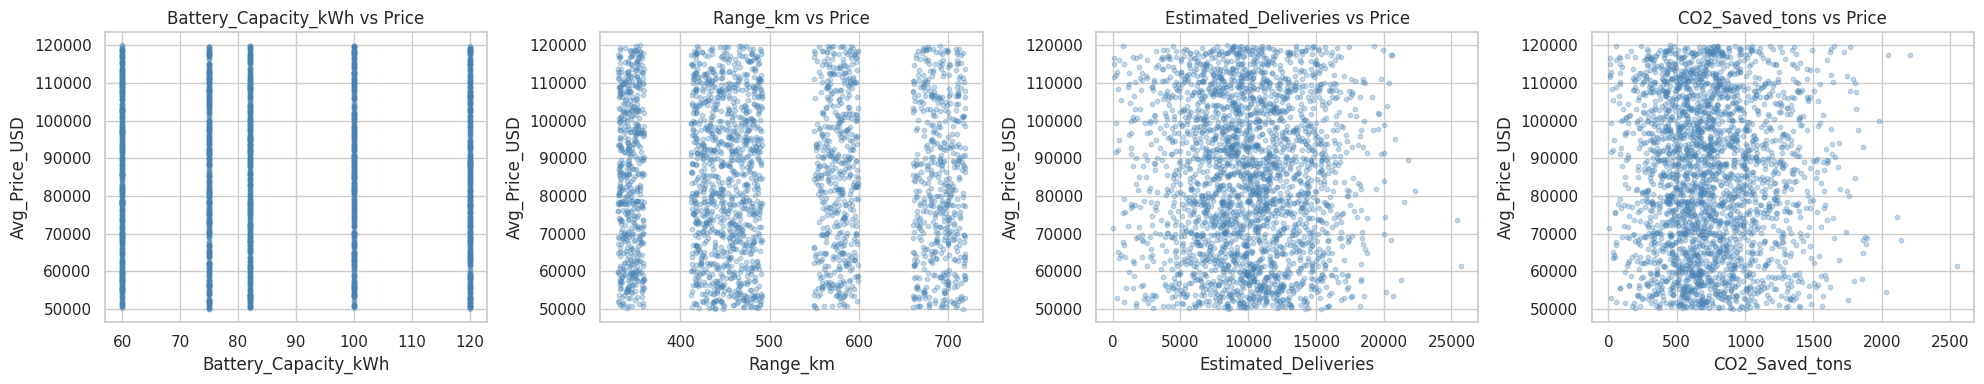

In [70]:
# Scatter plots of key features vs Avg_Price_USD to see linear relationships
feature_cols = [c for c in ['Battery_Capacity_kWh', 'Range_km', 'Estimated_Deliveries', 'CO2_Saved_tons'] if c in df.columns]

fig, axes = plt.subplots(1, len(feature_cols), figsize=(5 * len(feature_cols), 4))
for ax, col in zip(axes, feature_cols):
    ax.scatter(df[col], df['Avg_Price_USD'], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Avg_Price_USD')
    ax.set_title(f'{col} vs Price')
plt.tight_layout()
plt.show()

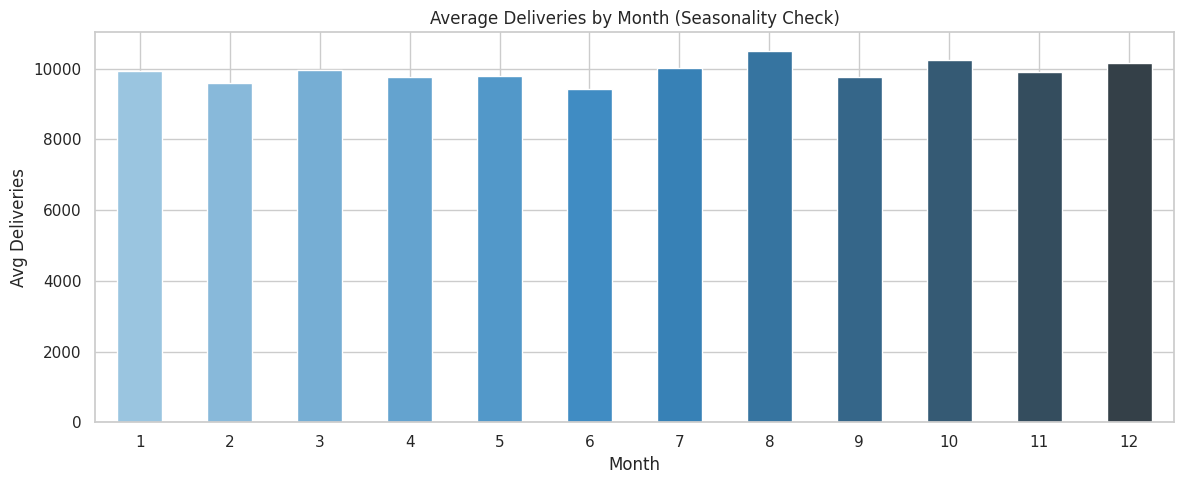

In [71]:
# Monthly seasonality — average deliveries per month across all years
if 'Month' in df.columns:
    monthly_avg = df.groupby('Month')['Estimated_Deliveries'].mean()
    monthly_avg.plot(kind='bar', color=sns.color_palette('Blues_d', 12), edgecolor='white')
    plt.title('Average Deliveries by Month (Seasonality Check)')
    plt.xlabel('Month')
    plt.ylabel('Avg Deliveries')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

---
## 5. Data Preprocessing

In [72]:
# Working on a copy so the original stays intact for time series analysis later
df_ml = df.copy()

for col in df_ml.select_dtypes(include=np.number).columns:
    if df_ml[col].isnull().sum() > 0:
        df_ml[col].fillna(df_ml[col].median(), inplace=True)

# Filling categorical missing values with mode
for col in df_ml.select_dtypes(include='object').columns:
    if df_ml[col].isnull().sum() > 0:
        df_ml[col].fillna(df_ml[col].mode()[0], inplace=True)

print("Missing values after imputation:", df_ml.isnull().sum().sum())

Missing values after imputation: 0


In [73]:
# im emoving the extreme outliers using IQR method on the target variable
Q1 = df_ml['Avg_Price_USD'].quantile(0.25)
Q3 = df_ml['Avg_Price_USD'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR

before = len(df_ml)
df_ml = df_ml[(df_ml['Avg_Price_USD'] >= lower) & (df_ml['Avg_Price_USD'] <= upper)]
print(f"Removed {before - len(df_ml)} outlier rows. Remaining: {len(df_ml)}")

Removed 0 outlier rows. Remaining: 2640


In [74]:
# Encode categorical columns — Label Encoding for tree  based models
le_region = LabelEncoder()
le_model  = LabelEncoder()

if 'Region' in df_ml.columns:
    df_ml['Region_enc'] = le_region.fit_transform(df_ml['Region'])
if 'Model' in df_ml.columns:
    df_ml['Model_enc'] = le_model.fit_transform(df_ml['Model'])

print("Encoding done.")
df_ml[['Region', 'Region_enc', 'Model', 'Model_enc']].drop_duplicates().head(10)

Encoding done.


,Region,Region_enc,Model,Model_enc
0,Europe,1,Model S,2
1,Asia,0,Model X,3
2,North America,3,Model X,3
3,North America,3,Model 3,1
4,Middle East,2,Model Y,4
6,Asia,0,Model 3,1
7,Europe,1,Cybertruck,0
11,Asia,0,Cybertruck,0
12,Middle East,2,Model S,2
13,Asia,0,Model S,2


---
## 6. Feature Engineering

In [75]:
# Create meaningful derived features that might help regression models

# Delivery efficiency — how many units delivered per unit produced
df_ml['Delivery_Efficiency'] = df_ml['Estimated_Deliveries'] / (df_ml['Production_Units'] + 1)

# CO2 savings per delivery — environmental impact per car delivered
df_ml['CO2_per_Delivery'] = df_ml['CO2_Saved_tons'] / (df_ml['Estimated_Deliveries'] + 1)

# Range-to-battery ratio — a rough efficiency metric for the vehicle
if 'Battery_Capacity_kWh' in df_ml.columns and 'Range_km' in df_ml.columns:
    df_ml['Range_per_kWh'] = df_ml['Range_km'] / (df_ml['Battery_Capacity_kWh'] + 1)

# Quarter feature from Month — useful for seasonality
if 'Month' in df_ml.columns:
    df_ml['Quarter'] = ((df_ml['Month'] - 1) // 3) + 1

# Year since first data point — captures Tesla's overall growth trend
df_ml['Years_Since_Start'] = df_ml['Year'] - df_ml['Year'].min()

# Log transform of skewed features to make distributions more normal
for col in ['Estimated_Deliveries', 'Production_Units', 'CO2_Saved_tons']:
    if col in df_ml.columns:
        df_ml[f'Log_{col}'] = np.log1p(df_ml[col])

print("New features created:", ['Delivery_Efficiency', 'CO2_per_Delivery', 'Range_per_kWh',
                                  'Quarter', 'Years_Since_Start', 'Log_Estimated_Deliveries',
                                  'Log_Production_Units', 'Log_CO2_Saved_tons'])
df_ml.head(3)

New features created: ['Delivery_Efficiency', 'CO2_per_Delivery', 'Range_per_kWh', 'Quarter', 'Years_Since_Start', 'Log_Estimated_Deliveries', 'Log_Production_Units', 'Log_CO2_Saved_tons']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Region_enc,Model_enc,Delivery_Efficiency,CO2_per_Delivery,Range_per_kWh,Quarter,Years_Since_Start,Log_Estimated_Deliveries,Log_Production_Units,Log_CO2_Saved_tons
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,...,1,2,0.984545,0.105594,5.818182,2,8,9.778321,9.793840,7.530705
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,...,0,3,0.911645,0.065682,5.763158,1,0,8.242230,8.334472,5.523299
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,...,3,3,0.915234,0.071991,5.783133,1,4,9.037415,9.125871,6.407853


In [76]:
# Define feature set and target — we're predicting average vehicle price
feature_cols = [
    'Year', 'Month', 'Region_enc', 'Model_enc',
    'Estimated_Deliveries', 'Production_Units',
    'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
    'Delivery_Efficiency', 'CO2_per_Delivery', 'Range_per_kWh',
    'Quarter', 'Years_Since_Start',
    'Log_Estimated_Deliveries', 'Log_Production_Units', 'Log_CO2_Saved_tons'
]
feature_cols = [c for c in feature_cols if c in df_ml.columns]

X = df_ml[feature_cols]
y = df_ml['Avg_Price_USD']

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")


Feature matrix shape: (2640, 17)
Target shape: (2640,)


In [77]:
# Split into train and test sets — 80/20 split, no shuffle to respect temporal order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features — important for linear models, harmless for trees
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 2112, Test size: 528


---
## 7. Baseline & Multiple Regression Models

In [78]:
# Helper function to evaluate any regression model consistently
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae   = mean_absolute_error(y_te, preds)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    cv    = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f"{'='*55}")
    print(f"Model   : {name}")
    print(f"MAE     : ${mae:,.2f}")
    print(f"RMSE    : ${rmse:,.2f}")
    print(f"R²      : {r2:.4f}")
    print(f"CV R²   : {cv:.4f}  (5-fold)")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv, 'predictions': preds}

results = []

In [79]:
# Linear Regression — a simple baseline to benchmark everything else against
res = evaluate_model('Linear Regression', LinearRegression(), X_train_sc, X_test_sc, y_train, y_test)
results.append(res)

Model   : Linear Regression
MAE     : $16,730.48
RMSE    : $19,443.51
R²      : -0.0025
CV R²   : -0.0155  (5-fold)


In [80]:
# Ridge Regression — adds L2 regularization to handle multicollinearity
res = evaluate_model('Ridge Regression', Ridge(alpha=10), X_train_sc, X_test_sc, y_train, y_test)
results.append(res)

Model   : Ridge Regression
MAE     : $16,734.98
RMSE    : $19,438.14
R²      : -0.0019
CV R²   : -0.0087  (5-fold)


In [81]:
# Lasso Regression — L1 regularization that can zero out unimportant features
res = evaluate_model('Lasso Regression', Lasso(alpha=10), X_train_sc, X_test_sc, y_train, y_test)
results.append(res)

Model   : Lasso Regression
MAE     : $16,733.91
RMSE    : $19,436.48
R²      : -0.0018
CV R²   : -0.0078  (5-fold)


In [82]:
# Random Forest — ensemble of decision trees; handles non-linearity well
res = evaluate_model('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42),
                     X_train, X_test, y_train, y_test)
results.append(res)

Model   : Random Forest
MAE     : $17,001.68
RMSE    : $20,079.91
R²      : -0.0692
CV R²   : -0.0582  (5-fold)


In [83]:
# Gradient Boosting — sequential tree ensemble; often very accurate on tabular data
res = evaluate_model('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, random_state=42),
                     X_train, X_test, y_train, y_test)
results.append(res)

Model   : Gradient Boosting
MAE     : $17,161.39
RMSE    : $20,073.44
R²      : -0.0685
CV R²   : -0.0403  (5-fold)


In [84]:
# XGBoost — optimized gradient boosting; faster and typically better than vanilla GBM
res = evaluate_model('XGBoost', xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
                     X_train, X_test, y_train, y_test)
results.append(res)

Model   : XGBoost
MAE     : $18,772.17
RMSE    : $22,576.41
R²      : -0.3516
CV R²   : -0.2534  (5-fold)


In [85]:
# LightGBM — leaf-wise boosting; very fast and memory efficient on large datasets
res = evaluate_model('LightGBM', lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
                     X_train, X_test, y_train, y_test)
results.append(res)

Model   : LightGBM
MAE     : $17,497.35
RMSE    : $20,835.31
R²      : -0.1511
CV R²   : -0.1378  (5-fold)


In [86]:
# Compare all models side by side in a clean summary table
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'predictions'} for r in results])
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print("\n--- Model Comparison ---")
results_df


--- Model Comparison ---


,Model,MAE,RMSE,R2,CV_R2
0,Lasso Regression,16733.905575,19436.475502,-0.001760,-0.007799
1,Ridge Regression,16734.980461,19438.142944,-0.001932,-0.008663
2,Linear Regression,16730.477419,19443.508483,-0.002485,-0.015465
3,Gradient Boosting,17161.386504,20073.444096,-0.068495,-0.040285
4,Random Forest,17001.677055,20079.911852,-0.069184,-0.058233
5,LightGBM,17497.345067,20835.312606,-0.151142,-0.137784
6,XGBoost,18772.172272,22576.409856,-0.351570,-0.253365


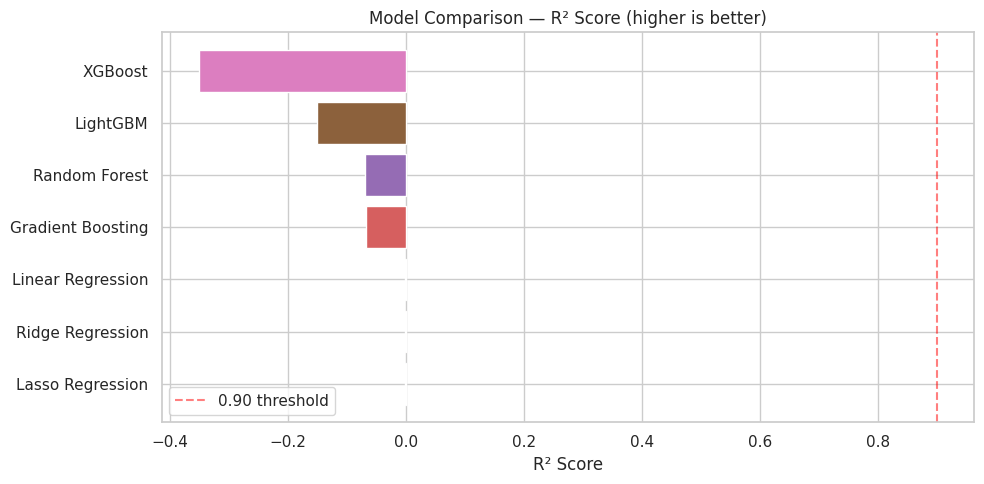

In [87]:
# Visual comparison of R² scores across all models
plt.figure(figsize=(10, 5))
bars = plt.barh(results_df['Model'], results_df['R2'], color=sns.color_palette('muted', len(results_df)))
plt.xlabel('R² Score')
plt.title('Model Comparison — R² Score (higher is better)')
plt.axvline(0.9, color='red', linestyle='--', alpha=0.5, label='0.90 threshold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 8. Hyperparameter Tuning - Best Model

In [88]:
# Tune XGBoost using GridSearchCV — searching over key hyperparameters
# This may take a few minutes depending on your hardware
param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.05, 0.1, 0.2],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0]
}

xgb_base = xgb.XGBRegressor(random_state=42, verbosity=0)
grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=3, scoring='r2',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print(f"Best CV R²   : {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV R²   : -0.0156


In [89]:
# Evaluate the tuned model on the held-out test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

mae_t  = mean_absolute_error(y_test, y_pred_best)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_t   = r2_score(y_test, y_pred_best)

print(f"Tuned XGBoost — Test Set Performance")
print(f"MAE  : ${mae_t:,.2f}")
print(f"RMSE : ${rmse_t:,.2f}")
print(f"R²   : {r2_t:.4f}")

Tuned XGBoost — Test Set Performance
MAE  : $17,006.87
RMSE : $19,843.04
R²   : -0.0441


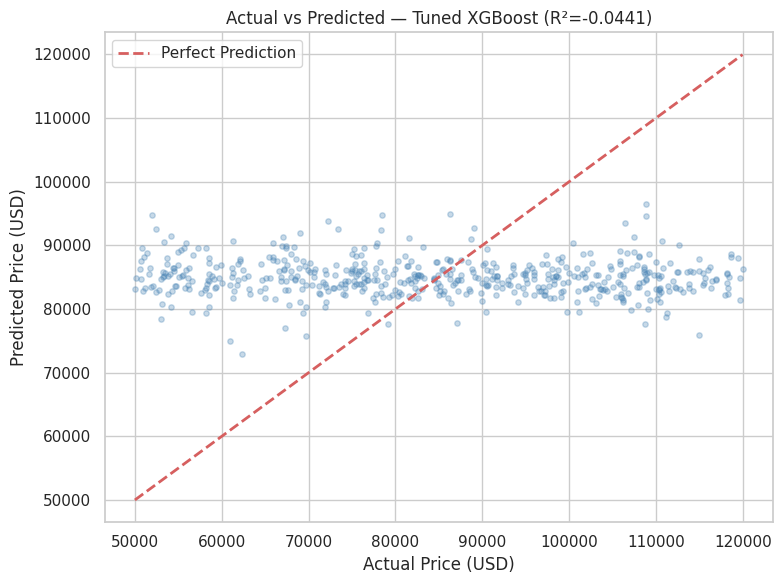

In [90]:
# Actual vs Predicted scatter — a well-tuned model should hug the diagonal
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=15, color='steelblue')
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title(f'Actual vs Predicted — Tuned XGBoost (R²={r2_t:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

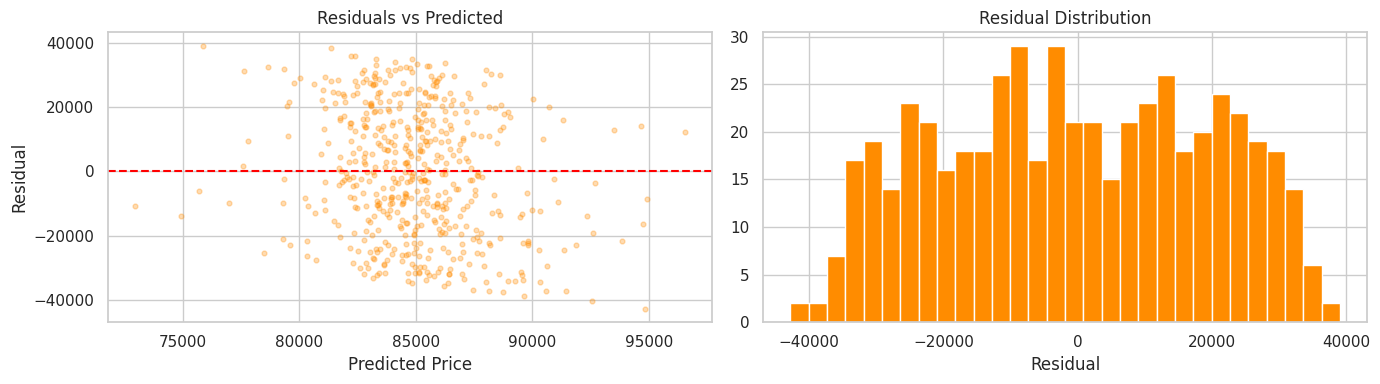

In [91]:
# Residual plot — residuals should be randomly scattered around zero
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=12, color='darkorange')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

residuals.hist(bins=30, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
plt.tight_layout()
plt.show()

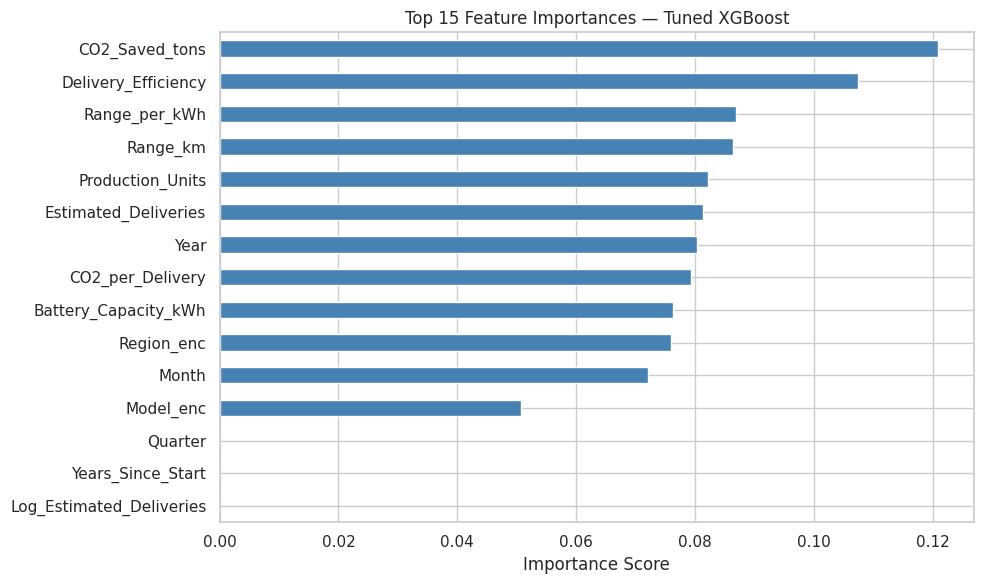

In [92]:
# Feature importance from the tuned XGBoost model
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — Tuned XGBoost')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 9. Time Series Forecasting — Estimated Deliveries

In [93]:
# Aggregate monthly deliveries to build a time series
ts_df = df.copy()
ts_df['Date'] = pd.to_datetime(ts_df['Year'].astype(str) + '-' + ts_df['Month'].astype(str).str.zfill(2) + '-01')
ts_monthly = ts_df.groupby('Date')['Estimated_Deliveries'].sum().sort_index()

print(f"Time series length: {len(ts_monthly)} months")
print(f"From {ts_monthly.index.min()} to {ts_monthly.index.max()}")
ts_monthly.head()

Time series length: 132 months
From 2015-01-01 00:00:00 to 2025-12-01 00:00:00


,Estimated_Deliveries
Date,
2015-01-01,183180
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


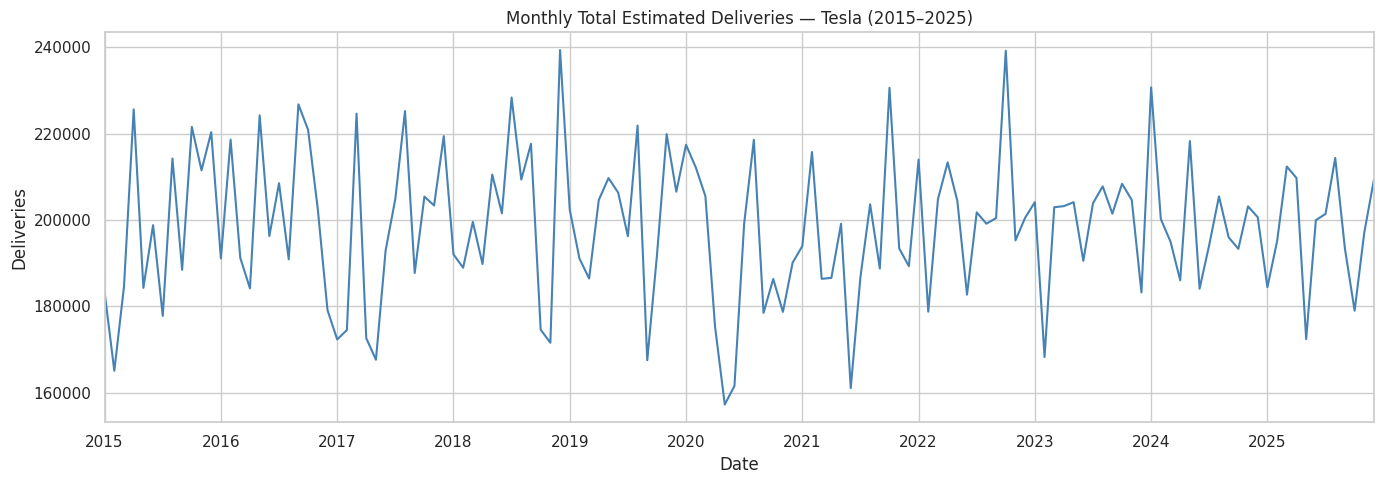

In [94]:
# Plot the full delivery time series to visualize growth and seasonality
plt.figure(figsize=(14, 5))
ts_monthly.plot(color='steelblue', linewidth=1.5)
plt.title('Monthly Total Estimated Deliveries — Tesla (2015–2025)')
plt.ylabel('Deliveries')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [95]:
# Augmented Dickey-Fuller test — checks if the series is stationary
result = adfuller(ts_monthly.dropna())
print("ADF Statistic :", round(result[0], 4))
print("p-value       :", round(result[1], 6))
print("Stationary    :", 'Yes' if result[1] < 0.05 else 'No — differencing may be needed')

ADF Statistic : -8.881
p-value       : 0.0
Stationary    : Yes


In [96]:
# Train/test split for time series — last 12 months as test
train_ts = ts_monthly[:-12]
test_ts  = ts_monthly[-12:]

print(f"Train: {train_ts.index.min()} → {train_ts.index.max()} ({len(train_ts)} months)")
print(f"Test : {test_ts.index.min()}  → {test_ts.index.max()} ({len(test_ts)} months)")

Train: 2015-01-01 00:00:00 → 2024-12-01 00:00:00 (120 months)
Test : 2025-01-01 00:00:00  → 2025-12-01 00:00:00 (12 months)


In [97]:
# Holt-Winters Exponential Smoothing — captures trend and seasonality
hw_model = ExponentialSmoothing(
    train_ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

hw_forecast = hw_model.forecast(12)

hw_mae  = mean_absolute_error(test_ts, hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test_ts, hw_forecast))
print(f"Holt-Winters | MAE: {hw_mae:,.0f}  |  RMSE: {hw_rmse:,.0f}")

Holt-Winters | MAE: 10,495  |  RMSE: 13,872


In [98]:
# SARIMA model — handles seasonal patterns with autoregressive terms
# Using simple (1,1,1)(1,1,1,12) — adjust if needed for your series
try:
    sarima = SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,1,12),
                     enforce_stationarity=False, enforce_invertibility=False)
    sarima_fit = sarima.fit(disp=False)
    sarima_forecast = sarima_fit.forecast(12)

    sarima_mae  = mean_absolute_error(test_ts, sarima_forecast)
    sarima_rmse = np.sqrt(mean_squared_error(test_ts, sarima_forecast))
    print(f"SARIMA       | MAE: {sarima_mae:,.0f}  |  RMSE: {sarima_rmse:,.0f}")
    sarima_ok = True
except Exception as e:
    print(f"SARIMA failed: {e}")
    sarima_ok = False

SARIMA       | MAE: 15,247  |  RMSE: 19,002


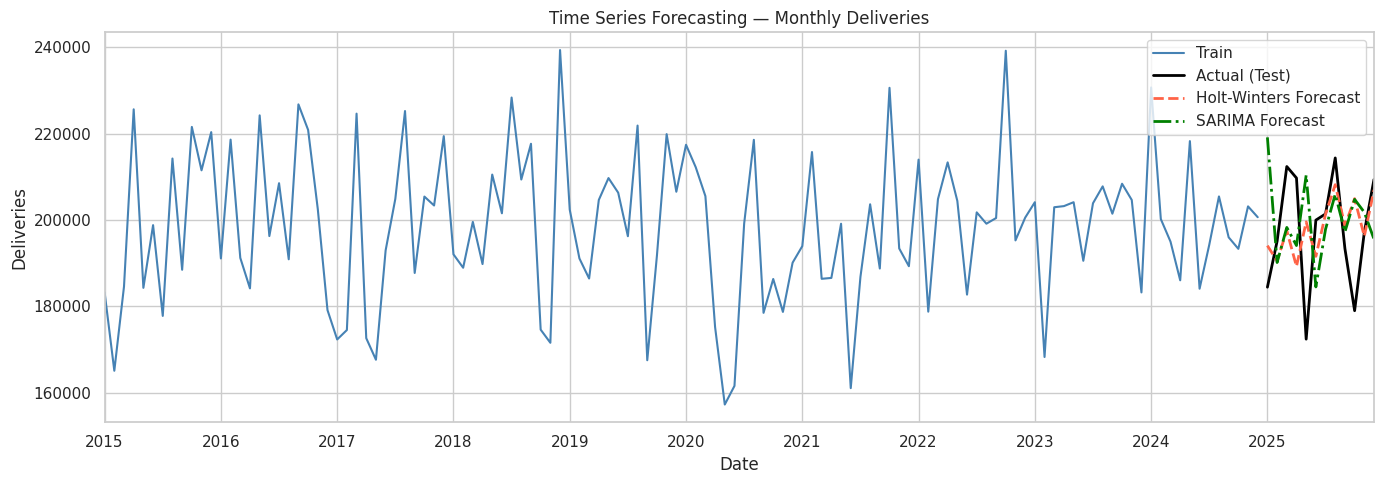

In [99]:
# Plot forecasts from both models alongside actual test data
plt.figure(figsize=(14, 5))
train_ts.plot(label='Train', color='steelblue', linewidth=1.5)
test_ts.plot(label='Actual (Test)', color='black', linewidth=2)
hw_forecast.plot(label='Holt-Winters Forecast', color='tomato', linestyle='--', linewidth=2)
if sarima_ok:
    sarima_forecast.plot(label='SARIMA Forecast', color='green', linestyle='-.', linewidth=2)
plt.title('Time Series Forecasting — Monthly Deliveries')
plt.ylabel('Deliveries')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
# Compare forecasting methods side-by-side in a table
ts_comparison = {
    'Holt-Winters': {'MAE': hw_mae, 'RMSE': hw_rmse}
}
if sarima_ok:
    ts_comparison['SARIMA'] = {'MAE': sarima_mae, 'RMSE': sarima_rmse}

ts_cmp_df = pd.DataFrame(ts_comparison).T
print("\n--- Time Series Model Comparison ---")
ts_cmp_df


--- Time Series Model Comparison ---


,MAE,RMSE
Holt-Winters,10494.593703,13871.698713
SARIMA,15247.473077,19002.182930


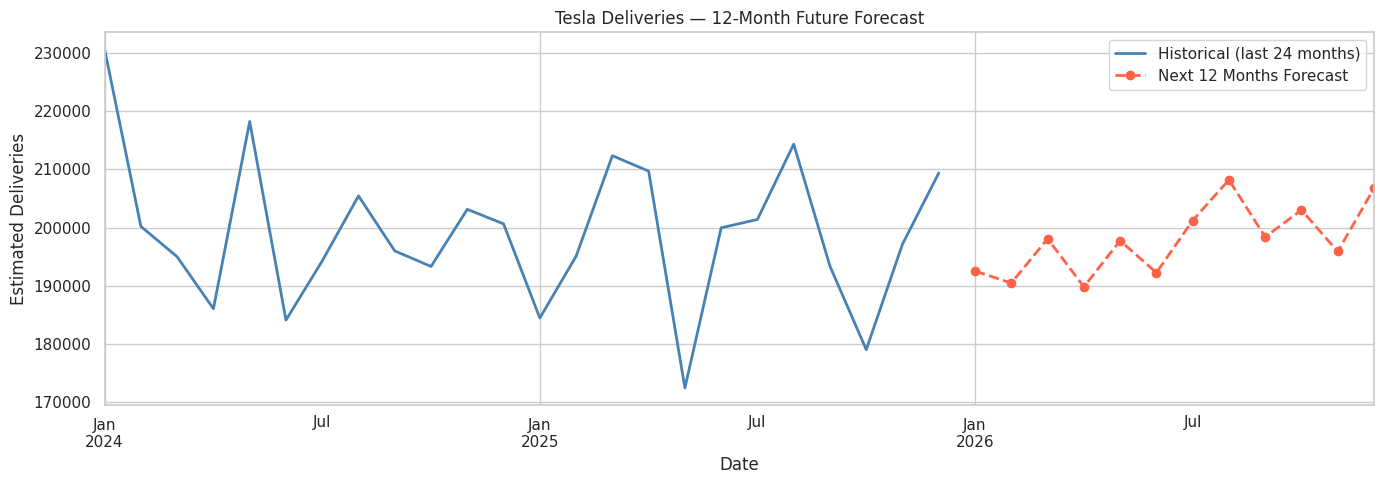


Future 12-month forecast:
2026-01-01    192,503
2026-02-01    190,435
2026-03-01    198,071
2026-04-01    189,794
2026-05-01    197,737
2026-06-01    192,220
2026-07-01    201,206
2026-08-01    208,206
2026-09-01    198,375
2026-10-01    203,017
2026-11-01    195,870
2026-12-01    206,739
Freq: MS, dtype: object


In [101]:
# Forecast the next 12 months beyond the dataset using the best TS model
best_ts_model = ExponentialSmoothing(
    ts_monthly,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

future_forecast = best_ts_model.forecast(12)

plt.figure(figsize=(14, 5))
ts_monthly[-24:].plot(label='Historical (last 24 months)', color='steelblue', linewidth=2)
future_forecast.plot(label='Next 12 Months Forecast', color='tomato', linestyle='--', linewidth=2, marker='o')
plt.title('Tesla Deliveries — 12-Month Future Forecast')
plt.ylabel('Estimated Deliveries')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

print("\nFuture 12-month forecast:")
print(future_forecast.apply(lambda x: f"{x:,.0f}"))

---
## 10. Summary & conclusions

In [103]:
print("End-to-End ML PIPELINE — SUMMARY")
print("-"*60)

print("\n[1] PREPROCESSING")
print("    - Median imputation for numerics, mode for categoricals")
print("    - IQR-based outlier removal on Avg_Price_USD")
print("    - Label encoding for Region and Model")

print("\n[2] EDA")
print("    - Price distribution, yearly trends, regional demand")
print("    - Correlation analysis, scatter plots, seasonality check")

print("\n[3] FEATURE ENGINEERING")
print("    - Delivery efficiency, CO2/delivery, range/kWh")
print("    - Quarter, years since start, log-transforms")

print("\n[4] REGRESSION MODELING")
best_reg = results_df.iloc[0]
print(f"    - 6 models tested; best: {best_reg['Model']}")
print(f"    - Test R²={best_reg['R2']:.4f}, MAE=${best_reg['MAE']:,.0f}")

print("\n[5] HYPERPARAMETER TUNING")
print(f"    - GridSearchCV on XGBoost over 5-dim param grid")
print(f"    - Tuned Test R²={r2_t:.4f}, MAE=${mae_t:,.0f}")

print("\n[6] TIME SERIES FORECASTING")
print(f"    - Holt-Winters: MAE={hw_mae:,.0f}, RMSE={hw_rmse:,.0f}")
if sarima_ok:
    print(f"    - SARIMA      : MAE={sarima_mae:,.0f}, RMSE={sarima_rmse:,.0f}")
print("    - 12-month forward forecast generated")


End-to-End ML PIPELINE — SUMMARY
------------------------------------------------------------

[1] PREPROCESSING
    - Median imputation for numerics, mode for categoricals
    - IQR-based outlier removal on Avg_Price_USD
    - Label encoding for Region and Model

[2] EDA
    - Price distribution, yearly trends, regional demand
    - Correlation analysis, scatter plots, seasonality check

[3] FEATURE ENGINEERING
    - Delivery efficiency, CO2/delivery, range/kWh
    - Quarter, years since start, log-transforms

[4] REGRESSION MODELING
    - 6 models tested; best: Lasso Regression
    - Test R²=-0.0018, MAE=$16,734

[5] HYPERPARAMETER TUNING
    - GridSearchCV on XGBoost over 5-dim param grid
    - Tuned Test R²=-0.0441, MAE=$17,007

[6] TIME SERIES FORECASTING
    - Holt-Winters: MAE=10,495, RMSE=13,872
    - SARIMA      : MAE=15,247, RMSE=19,002
    - 12-month forward forecast generated


---
**Submitted by : Mahesh Shinde (Sanjivani College of Engineering)**